In [1]:
#Thêm thư viện
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import IPython.display as ipd #Thêm thư viện để display Audio

PHÂN TÍCH BIÊN ĐỘ TÍN HIỆU

Tín hiệu gốc:
	Biên độ tối đa: 32767.0
	Biên độ tối thiểu: -32768.0
	Biên độ trung bình: -0.1863372776596721
	Biên độ RMS: 8488.633679003105

Tín hiệu có nhiễu trắng:
	Biên độ tối đa: 34822.925523552534
	Biên độ tối thiểu: -34728.73908493021
	Biên độ trung bình: -0.08906496758484873
	Biên độ RMS: 8531.043903874703

Tín hiệu đã lọc Low-Pass (4500 Hz):
	Biên độ tối đa: 33303.58812920914
	Biên độ tối thiểu: -33797.873190613696
	Biên độ trung bình: -0.0885440835387926
	Biên độ RMS: 8403.535558573474

Tín hiệu đã lọc Bandpass (300-4000 Hz):
	Biên độ tối đa: 29451.66374817132
	Biên độ tối thiểu: -31226.900298965076
	Biên độ trung bình: -0.00347189841897277
	Biên độ RMS: 4661.486397298514

THÔNG TIN SNR

SNR mục tiêu: 20 dB (tín hiệu mạnh gấp 100.0 lần nhiễu)

SNR TRƯỚC KHI LỌC

Tín hiệu có nhiễu (trước khi lọc):
	SNR: 20.0 dB
	MSE: 720211.892097
	RMSE: 848.652987

SNR SAU KHI LỌC

Sau Low-Pass Filter (4500 Hz):
	SNR: -2.71 dB
	MSE: 134345057.696832
	RMSE: 11590.73

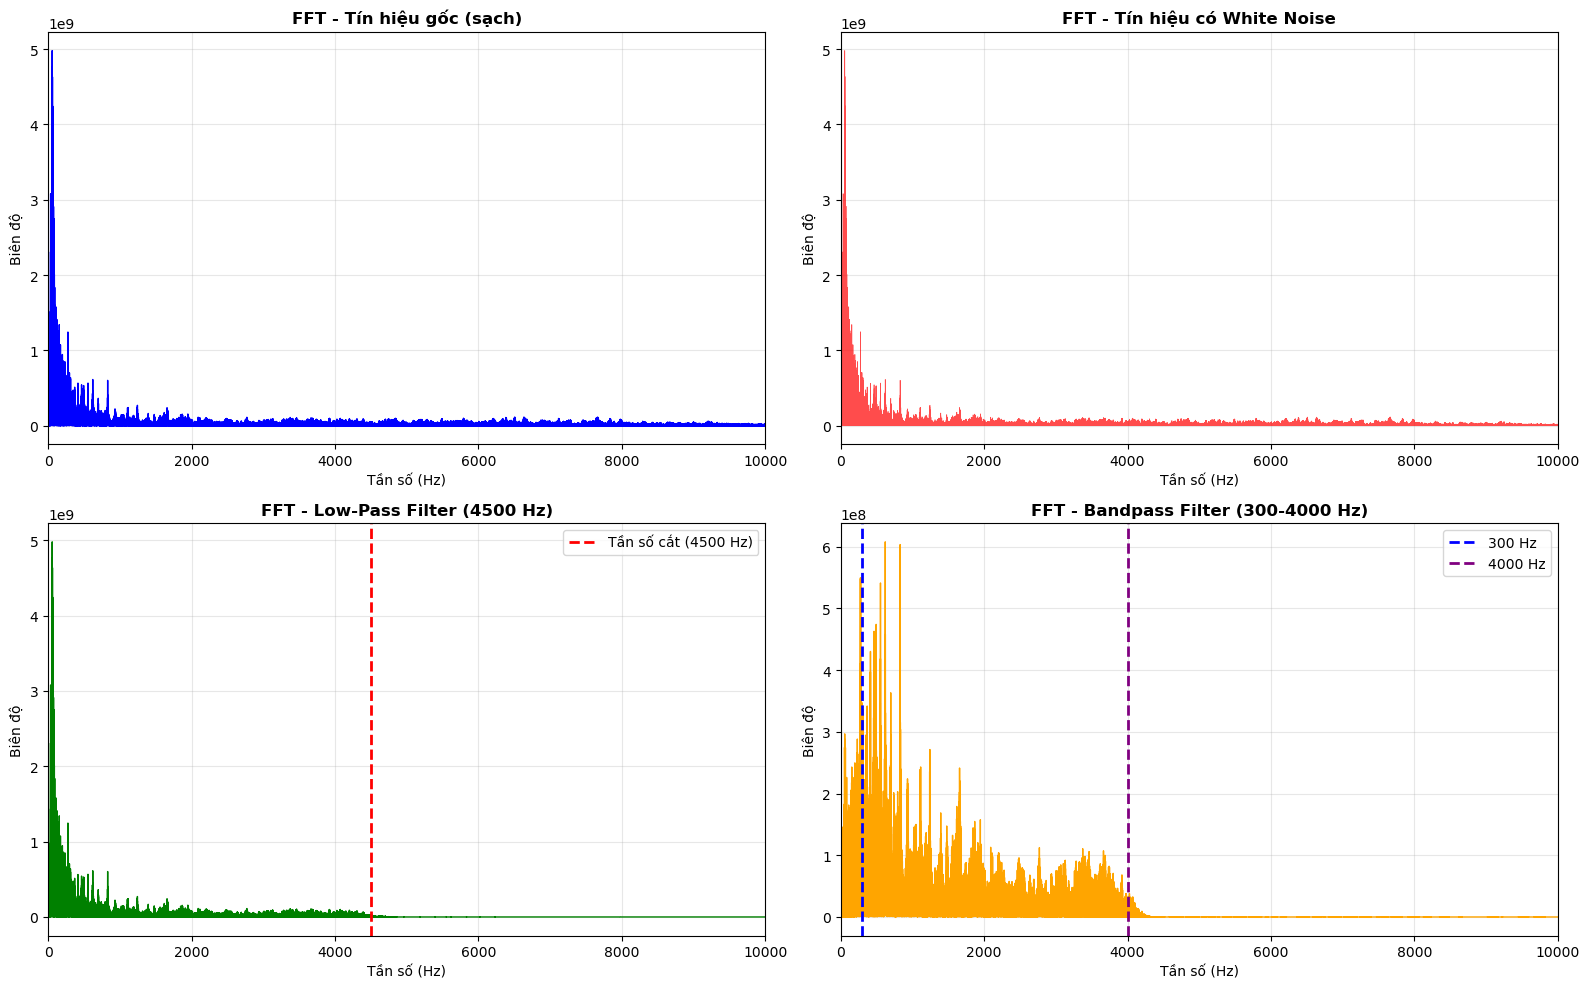

Đã lưu file: filtered_lowpass.wav
Đã lưu file: filtered_bandpass.wav


In [12]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firwin, lfilter

# ============================================================================
# ĐỌC FILE AUDIO
# ============================================================================
filename = 'smallgirl.wav'
sampleRate, audioData = wavfile.read(filename)

# Sử dụng kênh âm thanh đầu tiên nếu là âm thanh đa kênh
audioData = audioData[:, 0] if audioData.ndim > 1 else audioData

# Ép kiểu float64 ngay từ đầu để tránh overflow
audioData = audioData.astype(np.float64)

# ============================================================================
# CHUẨN HÓA TÍN HIỆU VÀ THÊM NHIỄU VỚI SNR KIỂM SOÁT
# ============================================================================

max_val = np.max(np.abs(audioData))
audioData_normalized = audioData / max_val

signal_power = np.mean(audioData_normalized ** 2)

SNR_dB = 20
SNR_linear = 10 ** (SNR_dB / 10)

noise_power_required = signal_power / SNR_linear

white_noise = np.random.normal(0, 1, audioData_normalized.shape)
white_noise = white_noise * np.sqrt(noise_power_required)

audioData_noise = (audioData_normalized + white_noise) * max_val

# ============================================================================
# PHƯƠNG PHÁP 1: LOW-PASS FILTER (4500 Hz)
# ============================================================================
filterOrder = 201
cutoffFrequency = 4500
cutoffNormalized = cutoffFrequency / (sampleRate / 2)

b_lp = firwin(filterOrder, cutoffNormalized, window='hamming')
a_lp = 1

yn_lowpass = lfilter(b_lp, a_lp, audioData_noise)

# ============================================================================
# PHƯƠNG PHÁP 2: BANDPASS FILTER (300-4000 Hz)
# ============================================================================
bandpass_low = 300
bandpass_high = 4000
bandpass_low_norm = bandpass_low / (sampleRate / 2)
bandpass_high_norm = bandpass_high / (sampleRate / 2)

bp_filterOrder = 201
b_bp = firwin(bp_filterOrder, [bandpass_low_norm, bandpass_high_norm], pass_zero=False)
a_bp = 1

yn_bandpass = lfilter(b_bp, a_bp, audioData_noise)

# ============================================================================
# HÀM PHÂN TÍCH BIÊN ĐỘ
# ============================================================================
def analyze_amplitude(sig, signal_name):
    s = np.array(sig, dtype=np.float64)
    v_max = float(np.max(s))
    v_min = float(np.min(s))
    v_mean = float(np.mean(s))
    v_rms = float(np.sqrt(np.mean(s ** 2)))
    print(signal_name + ':', flush=True)
    print('\tBiên độ tối đa: ' + str(v_max), flush=True)
    print('\tBiên độ tối thiểu: ' + str(v_min), flush=True)
    print('\tBiên độ trung bình: ' + str(v_mean), flush=True)
    print('\tBiên độ RMS: ' + str(v_rms), flush=True)
    print('', flush=True)

# ============================================================================
# HÀM TÍNH SNR
# ============================================================================
def calculate_snr(original, processed, method_name):
    o = np.array(original, dtype=np.float64)
    p = np.array(processed, dtype=np.float64)
    noise = p - o
    sig_pow = float(np.mean(o ** 2))
    noi_pow = float(np.mean(noise ** 2))
    snr = float(10 * np.log10(sig_pow / (noi_pow + 1e-10)))
    mse = noi_pow
    rmse = float(np.sqrt(mse))
    print(method_name + ':', flush=True)
    print('\tSNR: ' + str(round(snr, 2)) + ' dB', flush=True)
    print('\tMSE: ' + str(round(mse, 6)), flush=True)
    print('\tRMSE: ' + str(round(rmse, 6)), flush=True)
    print('', flush=True)
    return snr, mse, rmse

# ============================================================================
# PHÂN TÍCH BIÊN ĐỘ TÍN HIỆU
# ============================================================================
print('=' * 70, flush=True)
print('PHÂN TÍCH BIÊN ĐỘ TÍN HIỆU', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

analyze_amplitude(audioData, 'Tín hiệu gốc')
analyze_amplitude(audioData_noise, 'Tín hiệu có nhiễu trắng')
analyze_amplitude(yn_lowpass, 'Tín hiệu đã lọc Low-Pass (4500 Hz)')
analyze_amplitude(yn_bandpass, 'Tín hiệu đã lọc Bandpass (300-4000 Hz)')

# ============================================================================
# THÔNG TIN SNR
# ============================================================================
print('=' * 70, flush=True)
print('THÔNG TIN SNR', flush=True)
print('=' * 70, flush=True)
print('', flush=True)
print('SNR mục tiêu: ' + str(SNR_dB) + ' dB (tín hiệu mạnh gấp ' + str(SNR_linear) + ' lần nhiễu)', flush=True)
print('', flush=True)

# ============================================================================
# SNR TRƯỚC KHI LỌC
# ============================================================================
print('=' * 70, flush=True)
print('SNR TRƯỚC KHI LỌC', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

snr_before, mse_before, rmse_before = calculate_snr(
    audioData, audioData_noise, 'Tín hiệu có nhiễu (trước khi lọc)'
)

# ============================================================================
# SNR SAU KHI LỌC
# ============================================================================
print('=' * 70, flush=True)
print('SNR SAU KHI LỌC', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

snr_lowpass, mse_lowpass, rmse_lowpass = calculate_snr(
    audioData, yn_lowpass, 'Sau Low-Pass Filter (4500 Hz)'
)

snr_bandpass, mse_bandpass, rmse_bandpass = calculate_snr(
    audioData, yn_bandpass, 'Sau Bandpass Filter (300-4000 Hz)'
)

# ============================================================================
# SO SÁNH HIỆU QUẢ LỌC
# ============================================================================
print('=' * 70, flush=True)
print('SO SÁNH HIỆU QUẢ LỌC', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

header = 'Metric'.ljust(25) + 'Trước lọc'.rjust(15) + 'Low-Pass'.rjust(15) + 'Bandpass'.rjust(15)
print(header, flush=True)
print('-' * 70, flush=True)

row1 = 'SNR (dB)'.ljust(25) + str(round(snr_before, 2)).rjust(15) + str(round(snr_lowpass, 2)).rjust(15) + str(round(snr_bandpass, 2)).rjust(15)
print(row1, flush=True)

row2 = 'MSE'.ljust(25) + str(round(mse_before, 2)).rjust(15) + str(round(mse_lowpass, 2)).rjust(15) + str(round(mse_bandpass, 2)).rjust(15)
print(row2, flush=True)

row3 = 'RMSE'.ljust(25) + str(round(rmse_before, 2)).rjust(15) + str(round(rmse_lowpass, 2)).rjust(15) + str(round(rmse_bandpass, 2)).rjust(15)
print(row3, flush=True)
print('', flush=True)

# ============================================================================
# BIÊN ĐỘ NHIỄU ĐƯỢC GIỮ LẠI
# ============================================================================
print('=' * 70, flush=True)
print('BIÊN ĐỘ NHIỄU ĐƯỢC GIỮ LẠI', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

noise_original = np.array(audioData_noise - audioData, dtype=np.float64)
noise_remaining_lowpass = np.array(yn_lowpass - audioData, dtype=np.float64)
noise_remaining_bandpass = np.array(yn_bandpass - audioData, dtype=np.float64)

noise_rms_original = float(np.sqrt(np.mean(noise_original ** 2)))
noise_rms_lowpass = float(np.sqrt(np.mean(noise_remaining_lowpass ** 2)))
noise_rms_bandpass = float(np.sqrt(np.mean(noise_remaining_bandpass ** 2)))

pct_lowpass = round(noise_rms_lowpass / noise_rms_original * 100, 2)
pct_bandpass = round(noise_rms_bandpass / noise_rms_original * 100, 2)

print('Nhiễu gốc (RMS):       ' + str(round(noise_rms_original, 6)), flush=True)
print('Nhiễu sau Low-Pass:     ' + str(round(noise_rms_lowpass, 6)) + ' (' + str(pct_lowpass) + '%)', flush=True)
print('Nhiễu sau Bandpass:     ' + str(round(noise_rms_bandpass, 6)) + ' (' + str(pct_bandpass) + '%)', flush=True)
print('', flush=True)

# ============================================================================
# MỨC CẢI THIỆN SNR
# ============================================================================
print('=' * 70, flush=True)
print('MỨC CẢI THIỆN SNR', flush=True)
print('=' * 70, flush=True)
print('', flush=True)

improve_lp = round(snr_lowpass - snr_before, 2)
improve_bp = round(snr_bandpass - snr_before, 2)

if improve_lp >= 0:
    print('Low-Pass:  +' + str(improve_lp) + ' dB so với trước lọc', flush=True)
else:
    print('Low-Pass:  ' + str(improve_lp) + ' dB so với trước lọc', flush=True)

if improve_bp >= 0:
    print('Bandpass:  +' + str(improve_bp) + ' dB so với trước lọc', flush=True)
else:
    print('Bandpass:  ' + str(improve_bp) + ' dB so với trước lọc', flush=True)

print('', flush=True)

if snr_bandpass > snr_lowpass:
    print('=> Bandpass Filter cho kết quả tốt hơn', flush=True)
else:
    print('=> Low-Pass Filter cho kết quả tốt hơn', flush=True)

print('', flush=True)
sys.stdout.flush()

# ============================================================================
# VẼ BIỂU ĐỒ SO SÁNH TẦN SỐ (FFT)
# ============================================================================
freq_bins = len(audioData_noise)

fft_original = np.abs(np.fft.fft(audioData))[:freq_bins // 2]
fft_noisy = np.abs(np.fft.fft(audioData_noise))[:freq_bins // 2]
fft_lowpass = np.abs(np.fft.fft(yn_lowpass))[:freq_bins // 2]
fft_bandpass = np.abs(np.fft.fft(yn_bandpass))[:freq_bins // 2]

frequencies = np.fft.fftfreq(freq_bins, 1 / sampleRate)[:freq_bins // 2]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(frequencies, fft_original, 'b-', linewidth=1)
axes[0, 0].set_title('FFT - Tín hiệu gốc (sạch)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tần số (Hz)')
axes[0, 0].set_ylabel('Biên độ')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, 10000])

axes[0, 1].plot(frequencies, fft_noisy, 'r-', linewidth=0.5, alpha=0.7)
axes[0, 1].set_title('FFT - Tín hiệu có White Noise', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tần số (Hz)')
axes[0, 1].set_ylabel('Biên độ')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 10000])

axes[1, 0].plot(frequencies, fft_lowpass, 'g-', linewidth=1)
axes[1, 0].axvline(4500, color='red', linestyle='--', linewidth=2, label='Tần số cắt (4500 Hz)')
axes[1, 0].set_title('FFT - Low-Pass Filter (4500 Hz)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tần số (Hz)')
axes[1, 0].set_ylabel('Biên độ')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 10000])
axes[1, 0].legend()

axes[1, 1].plot(frequencies, fft_bandpass, 'orange', linewidth=1)
axes[1, 1].axvline(300, color='blue', linestyle='--', linewidth=2, label='300 Hz')
axes[1, 1].axvline(4000, color='purple', linestyle='--', linewidth=2, label='4000 Hz')
axes[1, 1].set_title('FFT - Bandpass Filter (300-4000 Hz)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tần số (Hz)')
axes[1, 1].set_ylabel('Biên độ')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 10000])
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('fft_comparison.png', dpi=150)
plt.show()

# ============================================================================
# LƯU FILE ÂM THANH ĐÃ LỌC
# ============================================================================
wavfile.write('filtered_lowpass.wav', sampleRate, yn_lowpass.astype(np.int16))
wavfile.write('filtered_bandpass.wav', sampleRate, yn_bandpass.astype(np.int16))

print('Đã lưu file: filtered_lowpass.wav', flush=True)
print('Đã lưu file: filtered_bandpass.wav', flush=True)